# Iris Classifier – Walk-Through Notebook
Building Your First AI Model

In [2]:
# Cell 1 – Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os

print('Libraries imported successfully!')

Libraries imported successfully!


In [3]:
# Cell 2 – Load & explore the data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names  = iris.target_names

print('Dataset shape:', X.shape)
print('Features:',      feature_names)
print('Classes:',       target_names)

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
# Cell 3 – Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training samples:', len(X_train))
print('Test samples:',     len(X_test))

Training samples: 120
Test samples: 30


In [5]:
# Cell 4 – Scale the features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print('Features scaled.')

Features scaled.


In [6]:
# Cell 5 – Train the model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [7]:
# Cell 6 – Evaluate
y_pred   = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')
print()
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 100.00%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



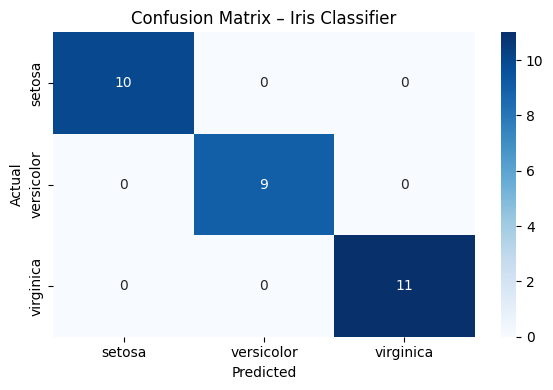

In [8]:
# Cell 7 – Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix – Iris Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()